In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tda_methods import LSTMAutoencoder, GeometryConverter, PersistencePlotter, TakensEmbedding, WassersteinDistance, \
            plot_3d_points, numpy_to_torch, window_2d_sequence_to_3d, write_results_to_file, \
            plot_all_features_in_2d_array, plot_latent_evolution_grid, read_yaml_params
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path


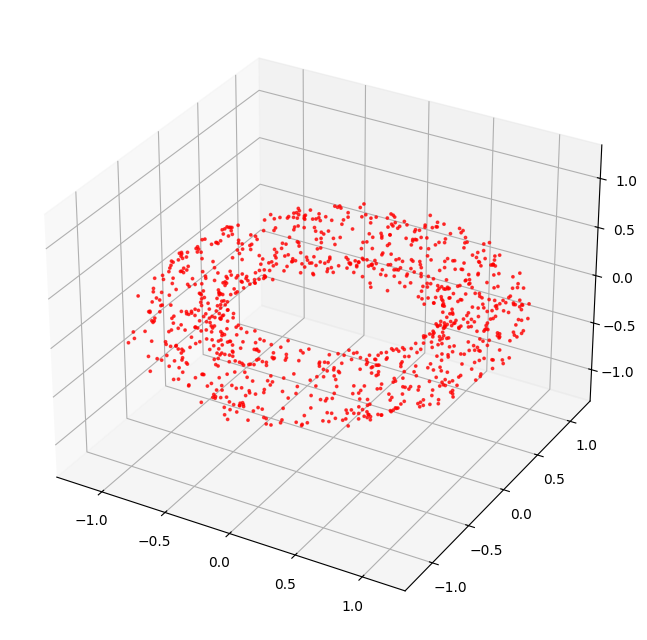

In [2]:
"Torus/Sphere data"

rng     = np.random.default_rng()
start_point, end_point, n_points = 0, 2*np.pi, 1000
u_angle = rng.uniform(start_point, end_point, n_points)
v_angle = rng.uniform(start_point, end_point, n_points)

# u, v = np.meshgrid(u, v)

R_major   = 1
r_tube    = R_major/4
converter = GeometryConverter(R_major, r_tube)
x, y, z   = converter.convert_angles_to_torus_xyz(u_angle, v_angle)
# # x, y, z   = converter.convert_angles_to_sphere_xyz(u_angle, v_angle)
noise = rng.normal(0, 0.04, n_points)
x += noise  # Add some noise to v
y += noise  # Add some noise to u
z += noise  # Add some noise to both
geo_coordinates = np.column_stack((x, y, z))  # shape (N, 3)

# x1,y1,z1,x2,y2,z2 = converter.convert_angles_to_2torus_xyz(u_angle, v_angle, d_shift=R_major)
# geo_coordinates   = np.vstack([np.column_stack((x1,y1,z1)), np.column_stack((x2,y2,z2))])
plot_3d_points((geo_coordinates[:, 0], geo_coordinates[:, 1], geo_coordinates[:, 2]))


In [3]:
"persistence"

# persistence    = PersistencePlotter(max_dim=1)
# diagrams_list  = persistence.compute_persistence_diagrams(geo_coordinates)
# diagrams_clean = persistence.remove_inf(diagrams_list)
# entropy_array  = persistence.compute_entropy(diagrams_clean)
# persistence_images_list = persistence.compute_persistence_image(diagrams_clean)
# betti_curves_array      = persistence.compute_betti_curves(diagrams_clean)

# print("Persistence array:", entropy_array)
# print("Betti curves shape: (batch, homology_dim, filtration_steps) =", betti_curves_array.shape)

# persistence.plot_persistence_diagrams(diagrams_list)
# persistence.plot_entropy(entropy_array)
# persistence.plot_persistence_image(persistence_images_list[1])  # H1
# persistence.plot_betti_curves(betti_curves_array)


'persistence'

In [4]:
"timedelay embeddings"

# x  = np.linspace(0, 14*np.pi, 1000)
# y1 = (0.5+0.5*x) * np.sin(2*x + 1) + 0.04 * rng.normal(size=x.shape)
# y2 = 1.5*np.sin(2 * x) #+ 0.05 * (x-2)**1.2 #+ 0.02 * rng.normal(size=x.shape)
# plt.figure()
# plt.plot(x, y1, label='y1')
# plt.plot(x, y2, label='y2')
# plt.legend()
# plt.show()

# min_len = min(len(y1), len(y2))
# y1, y2  = y1[:min_len], y2[:min_len]

# time_delay, lag_dim = 20, 4
# y1_delay_embeddings = make_timedelay_embeddings(y1, time_delay, lag_dim)
# y1_now, y1_delayed  = y1_delay_embeddings[:, 0], y1_delay_embeddings[:, 1]

# # time_delay2, lag_dim2 = 20, 4
# y2_delay_embeddings = make_timedelay_embeddings(y2, time_delay, lag_dim)
# y2_now, y2_delayed  = y2_delay_embeddings[:, 0], y2_delay_embeddings[:, 1]
# plt.figure()
# # plt.scatter(y1_now, y1_delayed, s=4)
# plt.scatter(y2_now, y2_delayed, s=4)
# plt.show()

# # persistence stuff
# persistence  = PersistencePlotter(max_dim=1)
# n            = min(len(y1_delay_embeddings), len(y2_delay_embeddings))
# y_all        = np.hstack((y1_delay_embeddings[:n], y2_delay_embeddings[:n]))
# # y_data       = np.column_stack((y1_now, y1_delayed))
# diagrams_list = persistence.compute_persistence_diagrams(y_all)
# persistence.plot_persistence_diagrams(diagrams_list, title="y_all")


'timedelay embeddings'

In [5]:
"⚽️ yaml params"
geo_params           = read_yaml_params(file_path="control_panel.yaml")

X_windowing_params   = geo_params["general"]["X_windowing"]
X_window_size        = X_windowing_params["window_size"]
X_stride_frac        = X_windowing_params["stride_frac"]

LSTMAE_params             = geo_params["general"]["LSTM_AE"]
lstmae_latent_dim         = LSTMAE_params["latent_dim"]
lstmae_encoder_hidden_dim = LSTMAE_params["encoder_hidden_dim"]
lstmae_decoder_hidden_dim = LSTMAE_params["decoder_hidden_dim"]
lstmae_patience           = LSTMAE_params["patience"]
lstm_ae_epochs            = LSTMAE_params["epochs"]
lstmae_learning_rate      = LSTMAE_params["learning_rate"]
lstmae_lambda_topo        = LSTMAE_params["lambda_topo"]
lstmae_batch_size         = LSTMAE_params["batch_size"]
topo_every                = LSTMAE_params["topo_every"]
N_runs                    = LSTMAE_params["N_runs"]
lambda_forecast           = LSTMAE_params["lambda_forecast"]

z_windowing_params   = geo_params["general"]["z_windowing"]
z_window_frac        = z_windowing_params["z_window_frac"]
z_stride_frac        = z_windowing_params["z_stride_frac"]

z_forecaster_params  = geo_params["general"]["z_forecaster"]
H_forecaster         = z_forecaster_params["H"]
hidden_dim_forecaster= z_forecaster_params["hidden_dim"]
forecaster_epochs    = z_forecaster_params["epochs"]
forecaster_patience  = z_forecaster_params["earlystop_patience"]
forecaster_lr        = z_forecaster_params["lr"]
forecaster_batch_size= z_forecaster_params["batch_size"]

persistence_params = geo_params["general"]["persistence"]
max_dim            = persistence_params["max_dim"]
pixel_size         = persistence_params["pixel_size"]


In [6]:
"⚽️ Setting up data"
rng     = np.random.default_rng()

num_timesteps = 3_000
timesteps     = np.linspace(0, 20*np.pi, num_timesteps)
# X1 = (2.0 * np.sin(0.2 * timesteps)) + 0.5 * np.sin(2*timesteps) + 0.03 * rng.normal(size=timesteps.shape)
# X2 = np.cos(3*timesteps + 1) + 0.5 * np.sin(2*timesteps) + 0.03 * rng.normal(size=timesteps.shape)
# X3 = -(4.0 * np.sin(0.8 * timesteps)) + 0.8 * np.sin(4*timesteps) + 0.03 * rng.normal(size=timesteps.shape)
X1 = np.sin(timesteps) + np.sin(0.1* timesteps**2) + 0.03 * rng.normal(size=timesteps.shape)
X2 = np.cos(1.7 * timesteps + X1) + 0.03 * rng.normal(size=timesteps.shape)
X3 = np.sin(X2 * X1) + 0.03 * rng.normal(size=timesteps.shape)
X  = np.column_stack((X1, X2, X3))

X_stride        = X_window_size//X_stride_frac
X_windows       = window_2d_sequence_to_3d(X, X_window_size, X_stride)
X_train_3d, X_test_3d = train_test_split(X_windows, test_size=0.2, random_state=42, shuffle=False)

# ============
# "⚽️ real dataset"

# import sys
# sys.path.append('../..')
# from src.preprocessing.data_loader_module import DatasetLoading

# dataset_loader_obj = DatasetLoading()
# X_all, y_all = dataset_loader_obj.load_beijing_data()

# # 1. split first (important)
# X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

# # 2. reshape to 2D
# N, T, F    = X_train.shape
# X_train_2d = X_train.reshape(-1, F)
# X_test_2d  = X_test.reshape(-1, F)

# # 3. fit scaler on train only
# scaler         = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train_2d)
# X_test_scaled  = scaler.transform(X_test_2d)

# # 4. reshape back to 3D
# X_train = X_train_scaled.reshape(N, T, F)
# X_test  = X_test_scaled.reshape(X_test.shape[0], T, F)
# print(X_train.shape, X_test.shape)



X shape (3000, 3) X_windows shape: (45, 250, 3)
X_train/test shape: (36, 250, 3) (9, 250, 3)


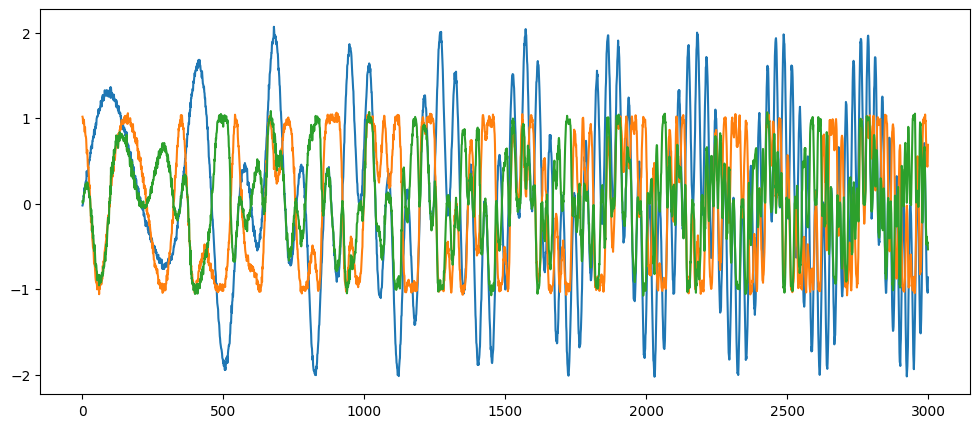

In [7]:
"⚽️ data processing"
# scaling works for 2d, so reshape to 2d, scale, and reshape back
scaler         = StandardScaler()
X_train_2d     = X_train_3d.reshape(-1, X_train_3d.shape[-1])
X_test_2d      = X_test_3d.reshape(-1, X_test_3d.shape[-1])
X_train = scaler.fit_transform(X_train_2d).reshape(X_train_3d.shape)
X_test  = scaler.transform(X_test_2d).reshape(X_test_3d.shape)

# takens_object   = TakensEmbedding(delay=8, embedding_dim=3)
# X_train_takens  = takens_object.make_timedelay_embeddings_grid(X_train)
# X_test_takens   = takens_object.make_timedelay_embeddings_grid(X_test)

print("X shape", X.shape, "X_windows shape:", X_windows.shape)
print("X_train/test shape:", X_train.shape, X_test.shape)

plt.figure(figsize=(12, 5))
plt.plot(X1, label='Original Data')
plt.plot(X2, label='Original Data')
plt.plot(X3, label='Original Data')


In [8]:
"[not working] circular/toroidal stuff"

class LSTMCircleAE(nn.Module):
    """Encode X->theta, embed to circle, decode X. Multivariate input supported."""
    def __init__(self, input_dim:int, enc_h:int=64, dec_h:int=64):
        super().__init__()
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.encoder = nn.LSTM(input_dim, enc_h, batch_first=True)
        self.to_theta = nn.Linear(enc_h, 1)              # (B,W,1)
        self.decoder = nn.LSTM(2, dec_h, batch_first=True)
        self.out = nn.Linear(dec_h, input_dim)

    def encode_theta(self, x:torch.Tensor)->torch.Tensor:
        h,_ = self.encoder(x)                            # (B,W,enc_h)
        return self.to_theta(h).squeeze(-1)              # (B,W)

    def embed_circle(self, theta:torch.Tensor)->torch.Tensor:
        return torch.stack([torch.cos(theta), torch.sin(theta)], dim=-1)  # (B,W,2)

    def decode(self, z_emb:torch.Tensor)->torch.Tensor:
        h,_ = self.decoder(z_emb)
        return self.out(h)                               # (B,W,D)

    def forward(self, x:torch.Tensor):
        theta = self.encode_theta(x)
        z_emb = self.embed_circle(theta)
        x_hat = self.decode(z_emb)
        return x_hat, theta

class ThetaForecaster(nn.Module):
    """Predict future theta sequence."""
    def __init__(self, hid:int=64):
        super().__init__()
        self.lstm = nn.LSTM(1, hid, batch_first=True)
        self.out = nn.Linear(hid, 1)

    def forward(self, theta:torch.Tensor)->torch.Tensor:
        # theta: (B,T)
        x = theta.unsqueeze(-1)           # (B,T,1)
        h,_ = self.lstm(x)
        return self.out(h).squeeze(-1)   # (B,T)

def train(model, forecaster, X, epochs:int, batch:int, lr:float, H:int, lam_fore:float=1.0):
    device = model.device
    model.to(device); forecaster.to(device)
    X = X.to(device)

    loader = DataLoader(TensorDataset(X), batch_size=batch, shuffle=True)
    opt = torch.optim.AdamW(list(model.parameters())+list(forecaster.parameters()), lr=lr)
    mse = nn.MSELoss()

    for ep in range(epochs):
        total = 0.0
        for (xb,) in loader:
            xb = xb.to(device)

            theta = model.encode_theta(xb)

            theta_past = theta[:, :-H]
            theta_fut  = theta[:, H:]

            theta_pred = forecaster(theta_past)[:, :theta_fut.size(1)]

            # NEW: mix teacher + prediction noise
            theta_for_dec = 0.5 * theta_fut + 0.5 * theta_pred.detach()

            x_recon = model.decode(model.embed_circle(theta_for_dec))
            loss = mse(theta_pred, theta_fut)



            opt.zero_grad(); loss.backward(); opt.step()
            total += loss.item()

        if ep % 5 == 0:
            print(f"epoch {ep} avg {total/len(loader):.4f}")

# 1. Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Prepare Data 
X_train_tensor = torch.as_tensor(X_train, dtype=torch.float32).detach().clone()
X_test_tensor  = torch.as_tensor(X_test,  dtype=torch.float32).detach().clone()

# 3. Initialize Models
input_dim = X_train_tensor.shape[-1]
model = LSTMCircleAE(input_dim=input_dim)
forecaster = ThetaForecaster()

# 4. Train
train(
    model=model, 
    forecaster=forecaster, 
    X=X_train_tensor, 
    epochs=50, 
    batch=64, 
    lr=1e-3, 
    H=H_forecaster)

H = H_forecaster

mse = torch.nn.MSELoss()
model.eval(); forecaster.eval()

with torch.no_grad():
    theta = model.encode_theta(X_test_tensor.to(model.device))

    theta_past = theta[:, :-H]
    theta_pred = forecaster(theta_past)

    theta_pred_H = theta_pred[:, -H:]

    x_pred = model.decode(model.embed_circle(theta_pred_H))
    x_true = X_test_tensor[:, -H:, :].to(model.device)

    mse = torch.nn.MSELoss()(x_pred, x_true)
    print("Circle model X-MSE:", mse.item())
# =============
# simple lstm forecaster

class LSTMBaseline(nn.Module):
    """Direct multivariate X→X forecaster."""
    def __init__(self, input_dim:int, hidden_dim:int=64):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.out = nn.Linear(hidden_dim, input_dim)

    def forward(self, x:torch.Tensor)->torch.Tensor:
        h,_ = self.lstm(x)
        return self.out(h)  # (B,W,D)

def train_baseline(model, X, epochs:int, batch:int, lr:float, H:int):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    X = X.to(device)

    loader = DataLoader(TensorDataset(X), batch_size=batch, shuffle=True)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    mse = nn.MSELoss()

    for ep in range(epochs):
        total = 0.0
        for (xb,) in loader:
            xb = xb.to(device)

            x_past = xb[:, :-H, :]           # input
            x_future = xb[:, H:, :]          # target (aligned)

            pred = model(x_past)[:, -x_future.size(1):, :]

            loss = mse(pred, x_future)

            opt.zero_grad(); loss.backward(); opt.step()
            total += loss.item()

        if ep % 5 == 0:
            print(f"epoch {ep} avg {total/len(loader):.4f}")

baseline = LSTMBaseline(input_dim=X_train.shape[-1])
train_baseline(baseline, X_train_tensor, epochs=50, batch=32, lr=1e-3, H=H_forecaster)

# eval
baseline.eval()
with torch.no_grad():
    # Change X_test (numpy) to X_test_tensor (tensor)
    X_test_device = X_test_tensor.to(next(baseline.parameters()).device)

    x_past = X_test_device[:, :-H, :]
    x_true = X_test_device[:, -H:, :]

    pred = baseline(x_past)[:, -H:, :]
    
    # Using a local variable for the loss value to avoid confusion with the nn.MSELoss class
    test_mse = nn.MSELoss()(pred, x_true)

    print("Baseline MSE:", test_mse.item())


epoch 0 avg 0.0128
epoch 5 avg 0.0009
epoch 10 avg 0.0014
epoch 15 avg 0.0003
epoch 20 avg 0.0006
epoch 25 avg 0.0001
epoch 30 avg 0.0002
epoch 35 avg 0.0001
epoch 40 avg 0.0001
epoch 45 avg 0.0000
Circle model X-MSE: 1.1088999509811401
epoch 0 avg 1.0282
epoch 5 avg 0.8577
epoch 10 avg 0.7729
epoch 15 avg 0.5098
epoch 20 avg 0.3699
epoch 25 avg 0.2334
epoch 30 avg 0.1452
epoch 35 avg 0.1019
epoch 40 avg 0.0647
epoch 45 avg 0.0588
Baseline MSE: 0.127681702375412


Point cloud shape: (296, 150)
Original X shape: (3000, 3)


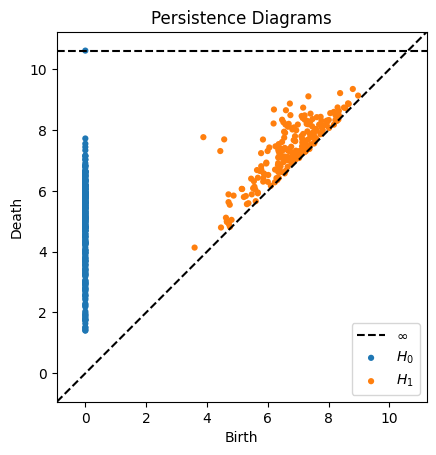

In [ ]:

"denoising direction"

def sliding_window_point_cloud(x: np.ndarray, L: int, stride: int = 1) -> np.ndarray:
    """Convert (T,d) time series into (N, d*L) point cloud."""
    rows, _ = x.shape
    N = (rows - L) // stride + 1
    return np.stack([x[i:i+L].reshape(-1) for i in range(0, N*stride, stride)])

X_pc = sliding_window_point_cloud(X, L=50, stride=10)
print("Point cloud shape:", X_pc.shape)
print("Original X shape:", X.shape)

# plt.plot(X_pc[:, 0], X_pc[:, 1], '.', alpha=0.5)
# plt.title("Point cloud from sliding windows")

pers_anal_obj = PersistencePlotter(max_dim=1)
diagrams_list  = pers_anal_obj.compute_persistence_diagrams(X_pc)
pers_anal_obj.plot_persistence_diagrams(diagrams_list)



In [ ]:
"🎯⚽️ models"

def topology_loss(x: torch.Tensor,
                  x_hat: torch.Tensor,
                  plotter,
                  wasser,
                  mode: str = "betti") -> torch.Tensor:
    """Computes Wasserstein distance between persistence features of x and x_hat."""
    x_np  = x.detach().cpu().numpy()
    xh_np = x_hat.detach().cpu().numpy()

    f_x  = plotter.compute_persistence_features(x_np, mode=mode)
    f_xh = plotter.compute_persistence_features(xh_np, mode=mode)

    if len(f_x) == 0 or len(f_xh) == 0:
        return torch.tensor(0.0, device=x.device)

    d = wasser.compute_wasserstein_distance(f_x, f_xh, delay=1).mean()
    return torch.tensor(d, device=x.device)#.clamp(0, 10)

def topology_loss_x_to_z(x, z, plotter, wasser, mode="image"):
    # Convert entire batch to numpy
    x_np = x.detach().cpu().numpy()
    z_np = z.detach().cpu().numpy()

    # Compute features for the whole batch
    # f_x and f_z will be shape (Batch, Feature_Dim)
    f_x = plotter.compute_persistence_features(x_np, mode=mode)
    f_z = plotter.compute_persistence_features(z_np, mode=mode)

    print("f_x:", f_x.shape, "f_z:", f_z.shape)
    print("f_x min/max:", np.min(f_x), np.max(f_x))

    # Check if we actually got features
    if f_x.size == 0 or f_z.size == 0 or np.all(f_x == 0):
        return torch.tensor(0.0, device=x.device, requires_grad=True)

    # Compute distance between the two batches of features
    # We use MSE here to follow the Rieck style: ||TDA(x) - TDA(z)||^2
    d = np.mean((f_x - f_z)**2)
    
    return torch.tensor(d, device=x.device, requires_grad=True)

def train_lstm_topo_ae(model,
                       X,
                       plotter,
                       wasser,
                       epochs,
                       batch_size,
                       lr,
                       lambda_topo,
                       device=None):

    device = device or model.device
    model.to(device)
    X = X.to(device)

    loader = DataLoader(TensorDataset(X), batch_size=batch_size, shuffle=True)

    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    mse = nn.MSELoss()

    for epoch in range(epochs):
        total = 0.0

        for step, (xb,) in enumerate(loader):
            xb = xb.to(device)
            x_hat, z = model(xb)

            # 1. Standard Reconstruction Loss
            loss_rec = mse(x_hat, xb)

            # 2. Topological Loss: Preservation of X's structure in Z
            # We compare the persistence features of the input to the latent code
            loss_topo = topology_loss_x_to_z(xb, z, plotter, wasser)

            # 3. Combined Loss
            loss = loss_rec + lambda_topo * loss_topo

            opt.zero_grad()
            loss.backward()
            opt.step()

        print(f"epoch {epoch} avg {total/len(loader):.4f}")

    return model

# unused? replaced by topology_loss_x_to_z
def topology_loss_latent(z, z_hat, plotter, wasser, mode="betti"):
    losses = []

    for i in range(z.shape[0]):
        # .unsqueeze(0) ensures the plotter sees a "batch" of 1 window
        # which matches the internal logic of _cache_diagrams
        zi  = z[i:i+1].detach().cpu().numpy() 
        zhi = z_hat[i:i+1].detach().cpu().numpy()

        # Ensure we have (1, sequence_length, features)
        if zi.ndim == 2:
            zi = zi[None, :, :]
        if zhi.ndim == 2:
            zhi = zhi[None, :, :]

        try:
            f_z  = plotter.compute_persistence_features(zi, mode=mode)
            f_zh = plotter.compute_persistence_features(zhi, mode=mode)
            
            if f_z.size == 0 or f_zh.size == 0:
                continue

            d = wasser.compute_wasserstein_distance(f_z, f_zh, delay=1)
            losses.append(torch.as_tensor(d.mean(), device=z.device))
        except Exception:
            # Handle cases where Ripser fails on very small/uniform latent noise
            continue

    if len(losses) == 0:
        return torch.tensor(0.0, device=z.device, requires_grad=True)

    return torch.stack(losses).mean()

def save_model(model, path: str):
    """Save model weights."""
    torch.save(model.state_dict(), path)

def load_model(path: str, input_dim: int, hidden_dim: int, device):
    """Reload trained model."""
    model = ZForecaster(input_dim=input_dim, hidden_dim=hidden_dim).to(device)
    model.load_state_dict(torch.load(path, map_location=device))
    model.eval()
    return model


In [ ]:
"⚽️ LSTMAE encoder: train + eval"

plotter = PersistencePlotter(max_dim=max_dim, pixel_size=pixel_size)
wasser  = WassersteinDistance()

X_train, X_test = numpy_to_torch(X_train), numpy_to_torch(X_test)

input_dim = X_train.shape[-1]

lstm_ae = LSTMAutoencoder(
    input_dim=input_dim,
    latent_dim=lstmae_latent_dim,
    encoder_hidden_dim=lstmae_encoder_hidden_dim,
    decoder_hidden_dim=lstmae_decoder_hidden_dim).to("cuda" if torch.cuda.is_available() else "cpu")

device = lstm_ae.device

# TRAIN (topology-aware AE)
train_lstm_topo_ae(
    model=lstm_ae,
    X=X_train,
    plotter=plotter,
    wasser=wasser,
    epochs=lstm_ae_epochs,
    batch_size=lstmae_batch_size,
    lr=lstmae_learning_rate,
    lambda_topo=lstmae_lambda_topo)

# inference
lstm_ae.eval()
with torch.no_grad():
    x_train_hat, z_train = lstm_ae(X_train.to(device))
    x_test_hat, z_test   = lstm_ae(X_test.to(device))

# normalize latent
mean = z_train.mean(dim=0)
std  = z_train.std(dim=0) + 1e-8
z_train = (z_train - mean) / std
z_test  = (z_test - mean) / std

print("z_train:", z_train.shape, "z_test:", z_test.shape)

# sanity check reconstruction
plt.plot(x_test_hat[2, :, 0].cpu(), label="recon")
plt.plot(X_test[2, :, 0].cpu(), label="true")
plt.legend()
plt.show()


In [ ]:
plt.scatter(z_train[0, :, 0].cpu(), z_train[0, :, 1].cpu(), label='Latent Dim 1')
plt.title('LSTM AE Latent Space')

In [ ]:
"⚽️ windowing latents z"

# actual_z_win_size = int(len(z_train) * z_window_frac)
# actual_z_stride   = int(len(z_train) * z_stride_frac)
# z_train_windows   = window_2d_sequence_to_3d(z_train, actual_z_win_size, actual_z_stride)
# z_test_windows    = window_2d_sequence_to_3d(z_test,  actual_z_win_size, actual_z_stride)

print(f"z_train={z_train.shape}, z_test={z_test.shape}")
# print(f"z_train_win= {z_train_windows.shape}, z_test_win= {z_test_windows.shape}")
plot_all_features_in_2d_array(z_train, window_number=1)
# plot_latent_evolution_grid(z_train_windows, max_latent_dims=8, n_plots_per_row=4)


In [ ]:
"⚠️ moved takens stuff temporarily here"

# takens_obj     = TakensEmbedding(delay=10, embedding_dim=3)
# z_train_takens = takens_obj.make_timedelay_embeddings_grid(z_train_windows)
# z_test_takens  = takens_obj.make_timedelay_embeddings_grid(z_test_windows)
# # plotter        = PersistencePlotter(max_dim=2, pixel_size=0.2)
# # dgms           = plotter.remove_inf(plotter.compute_persistence_diagrams(z_train_takens[0]))

# print(f"z_win_takens= {z_train_takens.shape}")

# plotter.plot_persistence_diagrams(dgms)

# # A(t) = mean_k corr(z[:,k], z[:,k+τ]) # acf decides the best window size

# window = 2
# plot_3d_points((z_train_takens[window][:, 0], z_train_takens[window][:, 1], z_train_takens[window][:, 2]), figsize=(6, 9))
# plot_3d_points((z_train_windows[window][:, 0], z_train_windows[window][:, 1], z_train_windows[window][:, 2]), figsize=(6, 9))

In [ ]:
# "⚠️⚽️ persistence + d_wasserstein + plotting"
# # TODO: is this cell really needed?

# plotter = PersistencePlotter(max_dim=2, pixel_size=0.2)
# d_wasser_obj = WassersteinDistance

# # ALIGNMENT FIX (⚠️ when H != 1, need to fix the [1:] bit in the next 4 lines)
# z_true_test = z_test_windows[1:]   # (9, 100, 8)
# z_hat_test  = Z_hat_test           # (9, 100, 8)

# z_true_train = z_train_windows[1:]
# z_hat_train  = Z_hat_train

# print("train aligned:", z_true_train.shape, z_hat_train.shape)
# print("test aligned :", z_true_test.shape, z_hat_test.shape)

# # PERSISTENCE FEATURES
# true_betti_train = plotter.compute_persistence_features(z_true_train, mode="betti")
# hat_betti_train  = plotter.compute_persistence_features(z_hat_train, mode="betti")

# true_betti_test = plotter.compute_persistence_features(z_true_test, mode="betti")
# hat_betti_test  = plotter.compute_persistence_features(z_hat_test, mode="betti")

# # TOPOLOGY LOSS (WASSERSTEIN)
# betti_dist_train = d_wasser_obj.compute_wasserstein_distance(true_betti_train, hat_betti_train, delay=1)
# betti_dist_test  = d_wasser_obj.compute_wasserstein_distance(true_betti_test, hat_betti_test, delay=1)

# # OUTPUT SHAPES + SUMMARY
# print("train betti dist shape:", betti_dist_train.shape)
# print("test betti dist shape :", betti_dist_test.shape)

# print("train mean topo error:", betti_dist_train.mean().item())
# print("test mean topo error :", betti_dist_test.mean().item())

# # ==============
# # X_hat, non-Takens

# # plotter        = PersistencePlotter(max_dim=2, pixel_size=0.2)
# # dgms           = plotter.remove_inf(plotter.compute_persistence_diagrams(Z_hat_train[0]))
# # z_betti_train    = plotter.compute_persistence_features(Z_hat_train, mode="betti")
# # z_image_train    = plotter.compute_persistence_features(Z_hat_train, mode="image")
# # z_diagram_train  = plotter.compute_persistence_features(Z_hat_train, mode="diagram")
# # z_landscape_train= plotter.compute_persistence_features(Z_hat_train, mode="landscape")

# # z_betti_test    = plotter.compute_persistence_features(Z_hat_test, mode="betti")
# # z_image_test    = plotter.compute_persistence_features(Z_hat_test, mode="image")
# # z_diagram_test  = plotter.compute_persistence_features(Z_hat_test, mode="diagram")
# # z_landscape_test= plotter.compute_persistence_features(Z_hat_test, mode="landscape")

# # d_wasser_obj         = WassersteinDistance
# # betti_dist_train     = d_wasser_obj.compute_wasserstein_distance(z_betti_train, delay=1)
# # image_dist_train     = d_wasser_obj.compute_wasserstein_distance(z_image_train, delay=1)
# # diagram_dist_train   = d_wasser_obj.compute_wasserstein_distance(z_diagram_train, delay=1)
# # landscape_dist_train = d_wasser_obj.compute_wasserstein_distance(z_landscape_train, delay=1)

# # betti_dist_test     = d_wasser_obj.compute_wasserstein_distance(z_betti_test, delay=1)
# # image_dist_test     = d_wasser_obj.compute_wasserstein_distance(z_image_test, delay=1)
# # diagram_dist_test   = d_wasser_obj.compute_wasserstein_distance(z_diagram_test, delay=1)
# # landscape_dist_test = d_wasser_obj.compute_wasserstein_distance(z_landscape_test, delay=1)

# # print(np.array2string(betti_dist_train, formatter={'float_kind': lambda x: f"{x:.2e}"}))
# # print(np.array2string(image_dist_train, formatter={'float_kind': lambda x: f"{x:.2e}"}))
# # print(np.array2string(diagram_dist_train, formatter={'float_kind': lambda x: f"{x:.2e}"}))
# # print(np.array2string(landscape_dist_train, formatter={'float_kind': lambda x: f"{x:.2e}"}))

# # d_wasser_obj.plot_all_wasserstein_distances(betti_dist_train, image_dist_train, diagram_dist_train, landscape_dist_train)

# # ===============
# # Takens

# # z_betti_train    = plotter.compute_persistence_features(z_train_takens, mode="betti")
# # z_image_train    = plotter.compute_persistence_features(z_train_takens, mode="image")
# # z_diagram_train  = plotter.compute_persistence_features(z_train_takens, mode="diagram")
# # z_landscape_train= plotter.compute_persistence_features(z_train_takens, mode="landscape")

# # z_betti_test    = plotter.compute_persistence_features(z_test_takens, mode="betti")
# # z_image_test    = plotter.compute_persistence_features(z_test_takens, mode="image")
# # z_diagram_test  = plotter.compute_persistence_features(z_test_takens, mode="diagram")
# # z_landscape_test= plotter.compute_persistence_features(z_test_takens, mode="landscape")

# # print("betti features shape:", z_betti_train.shape)
# # plotter.plot_persistence_grid(z_train_windows)
# # plotter.plot_persistence_image_grid(z_train_windows)
# # plotter.plot_betti_grid(z_train_windows)
# # plotter.plot_landscape_grid(z_train_windows, num_steps=128, K_layers=3)

# # d_wasser_obj         = WassersteinDistance
# # betti_dist_train     = d_wasser_obj.compute_wasserstein_distance(z_betti_train, delay=1)
# # image_dist_train     = d_wasser_obj.compute_wasserstein_distance(z_image_train, delay=1)
# # diagram_dist_train   = d_wasser_obj.compute_wasserstein_distance(z_diagram_train, delay=1)
# # landscape_dist_train = d_wasser_obj.compute_wasserstein_distance(z_landscape_train, delay=1)

# # betti_dist_test     = d_wasser_obj.compute_wasserstein_distance(z_betti_test, delay=1)
# # image_dist_test     = d_wasser_obj.compute_wasserstein_distance(z_image_test, delay=1)
# # diagram_dist_test   = d_wasser_obj.compute_wasserstein_distance(z_diagram_test, delay=1)
# # landscape_dist_test = d_wasser_obj.compute_wasserstein_distance(z_landscape_test, delay=1)

# # print(np.array2string(betti_dist_train, formatter={'float_kind': lambda x: f"{x:.2e}"}))
# # print(np.array2string(image_dist_train, formatter={'float_kind': lambda x: f"{x:.2e}"}))
# # print(np.array2string(diagram_dist_train, formatter={'float_kind': lambda x: f"{x:.2e}"}))
# # print(np.array2string(landscape_dist_train, formatter={'float_kind': lambda x: f"{x:.2e}"}))

# # d_wasser_obj.plot_all_wasserstein_distances(betti_dist_train, image_dist_train, diagram_dist_train, landscape_dist_train)


In [ ]:
"⚽️ results + comparisons"
from torchmetrics.regression import R2Score
from sklearn.linear_model import LinearRegression

def compute_r2(pred, true, device):
    r2 = R2Score().to(device)
    p = pred.reshape(-1, pred.shape[-1]).to(device)
    t = true.reshape(-1, true.shape[-1]).to(device)
    return r2(p, t).item()

def compute_linear_baseline(X_train, X_test):
    """Linear regression baseline in input space (next-step prediction)."""

    X_train_flat = X_train[:-1].reshape(X_train.shape[0]-1, -1).cpu().numpy()
    Y_train_flat = X_train[1:].reshape(X_train.shape[0]-1, -1).cpu().numpy()

    X_test_flat  = X_test[:-1].reshape(X_test.shape[0]-1, -1).cpu().numpy()
    Y_test_flat  = X_test[1:].reshape(X_test.shape[0]-1, -1).cpu().numpy()

    reg = LinearRegression().fit(X_train_flat, Y_train_flat)

    Y_pred = reg.predict(X_test_flat)
    Y_pred = Y_pred.reshape(Y_test_flat.shape)

    mse = np.mean((Y_pred - Y_test_flat) ** 2)
    return mse

def evaluate_run(model, X_test, device):
    """Reconstruction evaluation only (TopoAE setting)."""

    model.eval()
    with torch.no_grad():
        X_test = X_test.to(device)

        x_hat, _ = model(X_test)

        mse_model = ((x_hat - X_test) ** 2).mean().item()

        # naive baseline: copy last step forward (stupid baseline)
        x_naive = torch.cat([X_test[:, :1, :], X_test[:, :-1, :]], dim=1)
        mse_naive = ((x_naive - X_test) ** 2).mean().item()

        r2_model = compute_r2(x_hat, X_test, device)
        r2_naive = compute_r2(x_naive, X_test, device)

        pct_improvement = ((mse_naive - mse_model) / mse_naive) * 100

    return mse_model, r2_model, mse_naive, r2_naive, pct_improvement

# ---------------- RUN LOOP ----------------
results_storage = []

print(f"🚀 Starting {N_runs} runs")

for i in range(N_runs):
    metrics = evaluate_run(lstm_ae, X_test, lstm_ae.device)
    results_storage.append(metrics)
    mse_linear = compute_linear_baseline(X_train, X_test)

    print(
        f"Run {i+1}/{N_runs} | "
        f"MSE: {metrics[0]:.4f} | "
        f"R2: {metrics[1]:.3f} | "
        f"Improv: {metrics[4]:.2f}% | "
        f"Linear: {mse_linear:.4f}")

# ---------------- SUMMARY ----------------
res_arr = np.array(results_storage)

mean_mse = res_arr[:, 0].mean()
std_mse  = res_arr[:, 0].std()
mean_r2  = res_arr[:, 1].mean()
std_r2   = res_arr[:, 1].std()

results_line = (
    f"TopoAE | "
    f"MSE: {mean_mse:.4f} ± {std_mse:.4f} | "
    f"R2: {mean_r2:.3f} ± {std_r2:.3f}\n")

write_results_to_file(file="results.txt", line=results_line)
print(results_line)